# Preprocessing

In [15]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

from src.preprocessing import save_processed_data, save_test_processed_data, get_df_engineered
from src.preprocessing import save_complete_data
from utils.modeling import load_estimator
from src.preprocessing import add_aggregate_usage_features

In [2]:
save_processed_data()

In [3]:
df = pd.read_csv("../data/processed/df_processed.csv")
df

,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,customer_service_calls,churn
0,128,1,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,107,1,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,137,1,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,84,0,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,75,1,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2661,79,1,0,0,0,134.7,98,22.90,189.7,68,16.12,221.4,128,9.96,11.8,5,3.19,2,False
2662,192,1,0,1,36,156.2,77,26.55,215.5,126,18.32,279.1,83,12.56,9.9,6,2.67,2,False
2663,68,1,0,0,0,231.1,57,39.29,153.4,55,13.04,191.3,123,8.61,9.6,4,2.59,3,False
2664,28,2,0,0,0,180.8,109,30.74,288.8,58,24.55,191.9,91,8.64,14.1,6,3.81,2,False


## Feature Engineering

In [4]:
df_engineered = get_df_engineered(df)
df_engineered

,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,...,high_usage_service_risk,intl_plan_no_vmail,day_charge_per_minute,eve_charge_per_minute,night_charge_per_minute,intl_charge_per_minute,has_vmail_usage,vmail_plan_unused,new_customer,long_tenure
0,128,1,0,1,25,265.1,110,45.07,197.4,99,...,False,False,0.170011,0.085005,0.044994,0.270000,True,False,False,True
1,107,1,0,1,26,161.6,123,27.47,195.5,103,...,False,False,0.169988,0.085013,0.045008,0.270073,True,False,False,True
2,137,1,0,0,0,243.4,114,41.38,121.2,110,...,False,False,0.170008,0.084983,0.045018,0.269672,False,True,False,True
3,84,0,1,0,0,299.4,71,50.90,61.9,88,...,False,True,0.170007,0.084976,0.044997,0.269697,False,True,False,True
4,75,1,1,0,0,166.7,113,28.34,148.3,122,...,False,True,0.170006,0.085030,0.044997,0.270297,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2661,79,1,0,0,0,134.7,98,22.90,189.7,68,...,False,False,0.170007,0.084976,0.044986,0.270339,False,True,False,True
2662,192,1,0,1,36,156.2,77,26.55,215.5,126,...,False,False,0.169974,0.085012,0.045002,0.269697,True,False,False,True
2663,68,1,0,0,0,231.1,57,39.29,153.4,55,...,False,False,0.170013,0.085007,0.045008,0.269792,False,True,False,True
2664,28,2,0,0,0,180.8,109,30.74,288.8,58,...,False,False,0.170022,0.085007,0.045023,0.270213,False,True,True,False


In [5]:
df_engineered.to_csv("../data/processed/df_engineered.csv", index=False)

In [6]:
# preprocess the test data and save it as csv file
save_test_processed_data()

In [7]:
save_complete_data()

'Data saved successfully'

In [13]:
bst = load_estimator("../models/xgboost_classifier.pkl")
bst

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('bst', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['account_length','area_code','international_plan',...,'total_minutes', 'total_calls','total_charge']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


<Axes: ylabel='None'>

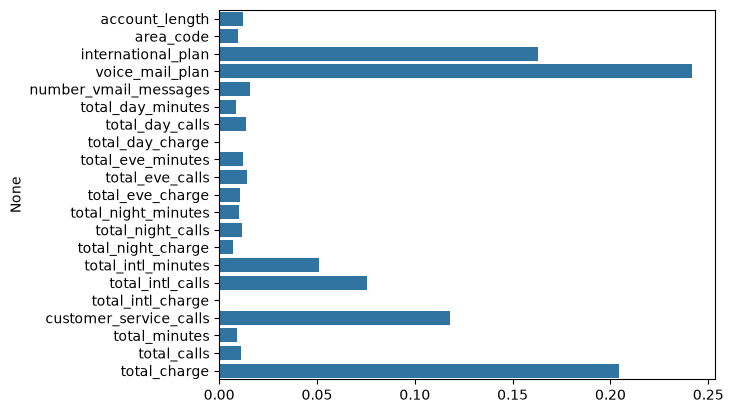

In [26]:
df = pd.read_csv('../data/processed/df_processed.csv').drop(columns=['churn'])
df = add_aggregate_usage_features(df)

sns.barplot(
    x=bst.named_steps['bst'].feature_importances_,
    y=df.columns,
    orient='h'
)

In [43]:

def save_bst_model_high_feature_importance_df(
        file_path: str = "../data/processed/bst_model_high_feature_importance.csv"
):
    # load xgboost model
    bst = load_estimator("../models/xgboost_classifier.pkl")
    feature_importances = bst.named_steps['bst'].feature_importances_
    
    # create dataframe
    df = pd.DataFrame(
        {
            "features": ["voice_mail_plan", "total_charge", "international_plan",
                         "customer_service_calls", "total_intl_calls", "total_intl_minutes"],
            "importance": [feature_importances[i] for i in [3, -1, 2, 17, 15, 14]]
		}
	)
    df.to_csv(file_path) # save dataframe

    return "High Feature Importance DataFrame saved to: " + file_path

save_bst_model_high_feature_importance_df()

'High Feature Importance DataFrame saved to: ../data/processed/bst_model_high_feature_importance.csv'